## Preliminares

In [1]:
# Importar modulos y funciones necesarias
import pandas as pd
import numpy as np
import os
from datetime import datetime
from sklearn.model_selection import cross_val_score, GridSearchCV, TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from category_encoders import TargetEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import plotly.express as px
import matplotlib.pyplot as plt
import shap
from src.transform import obtener_cols_financieras
from src.modeling import *

In [2]:
# Abrir archivo clean_data
data_folder = "data"
df = pd.read_parquet(f"{data_folder}/clean_data.parquet")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11366 entries, 0 to 11365
Data columns (total 55 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   CashAndCashEquivalents           11366 non-null  float64       
 1   CurrentDebt                      11366 non-null  float64       
 2   LongTermDebt                     11366 non-null  float64       
 3   TotalDebt                        11366 non-null  float64       
 4   StockholdersEquity               11366 non-null  float64       
 5   TotalAssets                      11366 non-null  float64       
 6   CurrentAssets                    11366 non-null  float64       
 7   CurrentLiabilities               11366 non-null  float64       
 8   OperatingCashFlow_TTM            11366 non-null  float64       
 9   InvestingCashFlow_TTM            11366 non-null  float64       
 10  FinancingCashFlow_TTM            11366 non-null  float64  

## Feature Engineering

In [ ]:
# Sección para crear variables en la fase de modelado. 

# Modelo de ensamblado de árboles RandomForest

In [5]:
# Se asegura el ordenamiento por fecha
df.sort_values(by='Date', inplace=True)

# Eliminar predictores

# Columnas Financieras: las columnas originales del balance. No son predictores, las mantuve para poder incluirlas en el reporte final
cols_financieras = obtener_cols_financieras() 

# Incluir las variables que tengan baja importancia para reducir el ruido (ej: importance < 0.01)
variables_no_significativas = [
    'RelativeAssets',
    'RelativeRevenue',
    'Revenue_Acceleration',
    'Sector',
    'CapEx_Acceleration',
    'Fcf_Acceleration',
]

predictores_a_eliminar = cols_financieras + variables_no_significativas + [
    # Ticker y fecha
    'Ticker',
    'Date',
    # Precios
    'Open',
    'Close',

    # Posibles labels:
    # 1) Ratios de valuación
    'PriceToBook', 
    'TrailingPE',
    'EnterpriseToEbitda',     
    # 2) Variables de tamaño (si se usan como label, quitar predictores RelativeAssets y RelativeRevenue para evitar Data Leakage)
    'MarketCap_Log1p',
    'EnterpriseValue_Log1p'
    ]

# Se define la variable objetivo y las variables predictoras
label = 'EnterpriseValue_Log1p'
X = df.drop(columns=predictores_a_eliminar) 
y = df[label]

# Columnas numéricas: 
numeric_cols = X.select_dtypes(include=np.number).columns.tolist()

# Variables categóricas:
categorical_cols = X.select_dtypes(exclude=np.number).columns.tolist()

# preprocesador: escala numéricas y codifica categóricas
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols),
    ('cat', TargetEncoder(smoothing= 10.0), categorical_cols)
])

pipe = Pipeline([
    ('pre', preprocessor),
    ('model', RandomForestRegressor(
        random_state=42,
        n_estimators=300,
        max_depth=15,
        min_samples_leaf=20,
        max_features=0.5,
        max_samples= 0.8,
        min_samples_split= 50         
        ))
])

print("Entrenando el modelo con datos completos...")
pipe.fit(X, y)
r2_completo = pipe.score(X, y)
print(f"Entrenamiento finalizado. R2 en datos completos: {r2_completo:.4f}")

Entrenando el modelo con datos completos...
Entrenamiento finalizado. R2 en datos completos: 0.5880


In [6]:
# Test de validación cruzada
# Configurar el validador de series temporales
tscv = TimeSeriesSplit(n_splits=5) # n_splits=5 creará 5 particiones temporales secuenciales

# 3. Test de validación cruzada temporal
cross_val_scores = cross_val_score(
    estimator=pipe, 
    X=X, 
    y=y, 
    cv=tscv,         
    scoring='r2',
    n_jobs=-1        
)

print(f"R² promedio Time Series CV: {cross_val_scores.mean():.4f} ± {cross_val_scores.std():.4f}")

R² promedio Time Series CV: 0.4344 ± 0.0242


In [7]:
# Importancia de factores en el modelo
rf_model = pipe.named_steps['model']
importances = rf_model.feature_importances_

# Obtener los nombres de las características después del preprocesamiento
preprocessor = pipe.named_steps['pre']
feature_names = preprocessor.get_feature_names_out()

feature_importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)
feature_importance_df.head(10)

,feature,importance
0,num__YearsSinceAdded,0.314628
19,cat__Industry,0.234497
14,num__Volume_Lag1_Log1p,0.148273
2,num__ProfitMargins,0.054592
1,num__OperatingMargins,0.048175
16,num__DebtToEquity_Log1p,0.019479
15,num__CapExToRevenue_Log1p,0.018770
12,num__QuarterlyReturn_Lag1,0.018491
8,num__Fcf_YoY,0.016842
7,num__Ebitda_YoY,0.015183


In [8]:
feature_importance_df.tail(10)

,feature,importance
17,num__QuarterlyVariance_Lag1_Log1p,0.014406
10,num__NetDebtToEbitda,0.013526
5,num__CurrentRatio,0.012943
6,num__Revenue_YoY,0.011934
9,num__CapEx_YoY,0.010887
4,num__ReturnOnAssets,0.010201
11,num__FcfToEbitda,0.009851
3,num__ReturnOnEquity,0.009552
18,num__Ebitda_Acceleration,0.009355
13,num__MarketCovariance_Lag1,0.008416


In [9]:
# Visualizar distribución de features
X.describe().T

,count,mean,std,min,25%,50%,75%,max
YearsSinceAdded,11366.0,15.030593,8.757649,0.000000,8.555556,13.444444,19.888889,51.000000
OperatingMargins,11366.0,0.145846,0.062957,-0.028267,0.100391,0.137161,0.181872,0.429983
ProfitMargins,11366.0,0.098811,0.052173,-0.168752,0.062973,0.091167,0.127881,0.325635
ReturnOnEquity,11366.0,0.283388,0.235727,-0.550368,0.127322,0.211889,0.348566,1.014134
ReturnOnAssets,11366.0,0.080561,0.059145,-0.127056,0.040681,0.064595,0.103144,0.290603
CurrentRatio,11366.0,1.646535,0.584792,0.386251,1.247875,1.528558,1.898563,3.852562
Revenue_YoY,11366.0,0.229923,0.613138,-0.896133,-0.163320,0.103862,0.442472,2.268262
Ebitda_YoY,11366.0,0.322616,0.811077,-0.982075,-0.215848,0.128592,0.602837,3.059740
Fcf_YoY,11366.0,0.484883,1.375093,-3.975549,-0.355230,0.054015,0.826402,4.374102
CapEx_YoY,11366.0,-0.470239,1.065567,-3.800727,-0.752651,-0.203566,0.247674,1.295979


## Aplicacion del modelo

Se generan 2 clusters segun las predicciones:
* Positive_Bias: si los residuos son mayores o iguales a cero.
* Negative_Bias: si los residuos son menores a cero.

In [10]:
# Se dividen los datos para predecir el valor de la última fecha disponible para cada ticker en el conjunto de test
X_train = X.iloc[:-len(df['Ticker'].unique())]  # Todos menos la última fecha de cada ticker
y_train = y.iloc[:-len(df['Ticker'].unique())]
X_test = X.iloc[-len(df['Ticker'].unique()):]   # Solo la última fecha de cada ticker
y_test = y.iloc[-len(df['Ticker'].unique()):]

# Recuperar el ticker usando el indice de y_test
tickers_test = df.loc[y_test.index, 'Ticker']

# Predicciones en el conjunto de test
y_pred = pipe.predict(X_test)

# Consolidar resultados individuales en un DataFrame
resultados_df = pd.DataFrame({
    'Ticker': tickers_test,
    'Predicted': y_pred,
    'Observed': y_test
})

# Calcular el residuo para cada predicción
resultados_df['Residuals'] = resultados_df['Predicted'] - resultados_df['Observed']

# Agrupar por ticker
resultados_agrupados = resultados_df.groupby('Ticker')[['Predicted', 'Observed', 'Residuals']].mean()

# Generar el Cluster sobre el promedio de los residuos
resultados_agrupados['Cluster'] = ['PositiveBias' if r >= 0 else 'NegativeBias' 
                                   for r in resultados_agrupados['Residuals']]

# Visualizar
fig = px.scatter(
    resultados_agrupados, 
    x='Observed', 
    y='Predicted', 
    color='Cluster',
    hover_name=resultados_agrupados.index, 
    labels={'Observed':'Valores Reales', 'Predicted':'Predicciones', 'Cluster':'Sesgo del Modelo'},
    title='Predicciones vs Reales (Agrupado por Ticker)'
)

# Línea de identidad perfecta
min_val = resultados_agrupados['Observed'].min()
max_val = resultados_agrupados['Observed'].max()
fig.add_shape(type='line', x0=min_val, y0=min_val, x1=max_val, y1=max_val,
              line=dict(color='black', dash='dash', width=2))
fig.show()

# Estadísticas por cluster a nivel Ticker
over_mask = resultados_agrupados['Cluster'] == 'PositiveBias'
under_mask = resultados_agrupados['Cluster'] == 'NegativeBias'

print("\nEstadísticas por cluster (a nivel de Ticker):")
print(f"Overprediction: {over_mask.sum()} tickers, residuo medio global: {resultados_agrupados.loc[over_mask, 'Residuals'].mean():.4f}")
print(f"Underprediction: {under_mask.sum()} tickers, residuo medio global: {resultados_agrupados.loc[under_mask, 'Residuals'].mean():.4f}")


Estadísticas por cluster (a nivel de Ticker):
Overprediction: 215 tickers, residuo medio global: 0.3550
Underprediction: 269 tickers, residuo medio global: -0.4381


In [11]:
# Ordenar resultados por residuos
resultados_agrupados = resultados_agrupados.sort_values(by='Residuals', ascending=False)

# Establer Ticker como columna para exportar resultados
resultados_agrupados.reset_index(inplace=True)

# Cálculo del error en porcentaje
resultados_agrupados['PercentError'] = ((resultados_agrupados['Predicted'] - resultados_agrupados['Observed'])/ resultados_agrupados['Observed'])*100

print(resultados_agrupados.head().to_string(index=False))

Ticker  Predicted  Observed  Residuals      Cluster  PercentError
  XRAY   9.509656  8.260550   1.249105 PositiveBias     15.121332
  CPHI   9.590614  8.439521   1.151093 PositiveBias     13.639313
   DVN  10.295668  9.171749   1.123919 PositiveBias     12.254144
    WU  10.790107  9.689756   1.100351 PositiveBias     11.355813
  SITE   9.574290  8.528288   1.046001 PositiveBias     12.265082


In [12]:
# Se genera el reporte final para research posterior
# Se filtra df para mantener solo la fila más reciente de cada empresa
df_latest = df.drop_duplicates(subset=['Ticker'], keep='last')

df_reporte = resultados_agrupados.merge(df_latest, how='left', on='Ticker') 

dia = datetime.now().day
mes = datetime.now().month
year = datetime.now().year

os.makedirs(f"{data_folder}/reports", exist_ok=True) # Crear carpeta si no existe

df_reporte.to_csv(f"{data_folder}/reports/{year}_{mes}_{dia}.csv", index=False)
print(f'Reporte exportado en la carpeta {data_folder}/reports.')
df_reporte.head()

Reporte exportado en la carpeta data/reports.


,Ticker,Predicted,Observed,Residuals,Cluster,PercentError,CashAndCashEquivalents,CurrentDebt,LongTermDebt,TotalDebt,...,Volume_Lag1_Log1p,CapExToRevenue_Log1p,DebtToEquity_Log1p,QuarterlyVariance_Lag1_Log1p,MarketCap_Log1p,EnterpriseValue_Log1p,Revenue_Acceleration,Ebitda_Acceleration,Fcf_Acceleration,CapEx_Acceleration
0,XRAY,9.509656,8.260550,1.249105,PositiveBias,15.121332,326.000,230.000,2006.000,2331.000,...,5.396114,0.028334,1.018338,3.804886,7.538140,8.260550,-0.209480,0.732531,-2.150190,-0.154687
1,CPHI,9.590614,8.439521,1.151093,PositiveBias,13.639313,8.505,11.457,2924.455,3055.314,...,3.980267,0.073052,2.686038,0.580872,7.439398,8.439521,0.289121,-0.412986,2.225492,-1.015941
2,DVN,10.295668,9.171749,1.123919,PositiveBias,12.254144,510.500,254.200,2455.700,2505.300,...,5.009315,0.128003,0.617248,0.207882,8.914241,9.171749,-0.000291,0.129206,-0.192083,2.206413
3,WU,10.790107,9.689756,1.100351,PositiveBias,11.355813,1463.442,382.000,7157.000,8567.000,...,6.266037,0.048115,1.050965,0.816121,8.601317,9.689756,-0.649931,-0.123922,0.611233,0.822567
4,SITE,9.574290,8.528288,1.046001,PositiveBias,12.265082,2819.000,201.776,4676.060,4909.659,...,4.278618,0.019892,0.486250,1.424875,8.358294,8.528288,-0.295975,-0.832633,0.431875,-0.338881


## Explicabilidad del Modelo (SHAP)

In [13]:
# Seleccionar un Ticker específico a evaluar
ticker_a_explicar = 'WY'

--- Explicación de la predicción para: WY ---


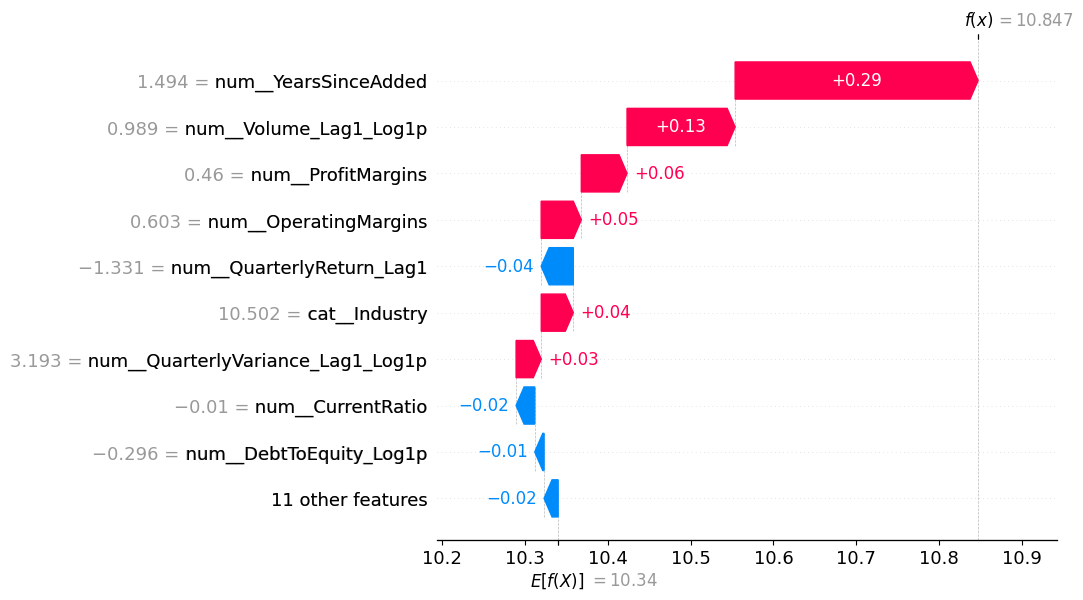

In [14]:
# Extraer los componentes del pipeline
preprocessor = pipe.named_steps['pre']
rf_model = pipe.named_steps['model']

# Transformar los datos de test (X_test) usando el preprocesador
X_test_transformed = preprocessor.transform(X_test)

# Obtener los nombres de las columnas transformadas
feature_names = preprocessor.get_feature_names_out()

# Crear un DataFrame con los datos transformados para que SHAP lea los nombres
X_test_shap = pd.DataFrame(X_test_transformed, columns=feature_names, index=X_test.index)

# Verificar que el ticker esté en los datos de test
if ticker_a_explicar in tickers_test.values:
    # Obtener la posición (índice entero) del ticker en el array de test
    idx = np.where(tickers_test == ticker_a_explicar)[0][0]
    
    # Extraer solo la fila del ticker seleccionado
    X_ticker_eval = X_test_shap.iloc[[idx]]
    
    # Inicializar el explicador de SHAP
    explainer = shap.TreeExplainer(rf_model)
    
    # Calcular los valores SHAP (solo para el ticker seleccionado para optimizar tiempo)
    shap_values = explainer(X_ticker_eval)
    
    print(f"--- Explicación de la predicción para: {ticker_a_explicar} ---")
    
    # Crear la figura y visualizar
    plt.figure(figsize=(10, 6))
    
    # Generar el gráfico de cascada (Waterfall plot)
    shap.plots.waterfall(shap_values[0], max_display=10)
    
else:
    print(f"El ticker {ticker_a_explicar} no se encuentra en el conjunto de test (tickers_test).")

## Anexo: optimización de hiper-parámetros

In [15]:
ejecutar_celda = False

if ejecutar_celda:
    nombre_modelo = "Random Forest"
    print(f"Configurando GridSearchCV para {nombre_modelo}")

    # Pipeline usando el preprocesador específico para Random Forest
    modelo_base = Pipeline(steps=[
        ('preprocesador', preprocessor),
        ('rf', RandomForestRegressor(random_state=42))
    ])

    param_grid = {
        'rf__n_estimators': [300],
        'rf__max_depth': [7, 10, 15, 20],
        'rf__min_samples_leaf': [20, 50, 100],
        'rf__min_samples_split': [50, 100, 200],
        'rf__max_samples': [0.6, 0.8],
        'rf__max_features': ['sqrt', 0.3, 0.5]
    }

    # Configurar el GridSearchCV
    grid_search = GridSearchCV(
        estimator=modelo_base,
        param_grid=param_grid,
        scoring='r2',
        cv=tscv,
        n_jobs=-1,
        verbose=2
    )

    # Entrenar con datos completos
    print(f"Iniciando búsqueda de hiperparámetros. Esto tomará unos minutos.")
    grid_search.fit(X, y)

    # Resultados
    print("\n--- Búsqueda Finalizada ---")
    print("Mejores hiperparámetros encontrados:")
    print(grid_search.best_params_)